In [1]:
import sys
sys.path.insert(0, "..")  # so we can import from src/

import pandas as pd
import matplotlib.pyplot as plt
from src.eda_helpers import (
    plot_class_balance, plot_sensor_pass_fail, top_variance_correlation_heatmap,
    plot_failure_rate_over_time, plot_pca_scatter, find_most_separable_sensors,
)

df = pd.read_csv("../data/processed/secom_clean.csv", parse_dates=["Timestamp"])
df.shape

(1567, 434)

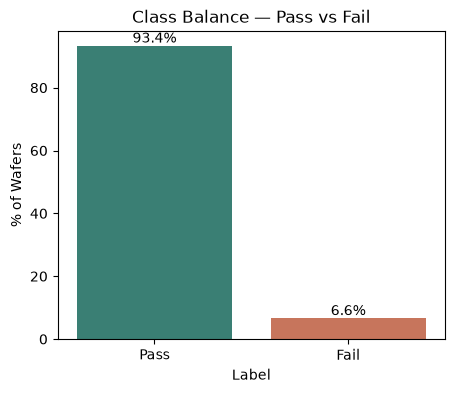

In [2]:
fig, ax = plt.subplots(figsize=(5, 4))
plot_class_balance(df, ax)
plt.savefig("../reports/figures/class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

In [3]:
top_sensors = find_most_separable_sensors(df, top_n=6)
top_sensors

,Sensor,Standardized_Mean_Gap
0,Sensor_60,0.626524
1,Sensor_104,0.607336
2,Sensor_511,0.528752
3,Sensor_349,0.525317
4,Sensor_432,0.481663
5,Sensor_435,0.447025


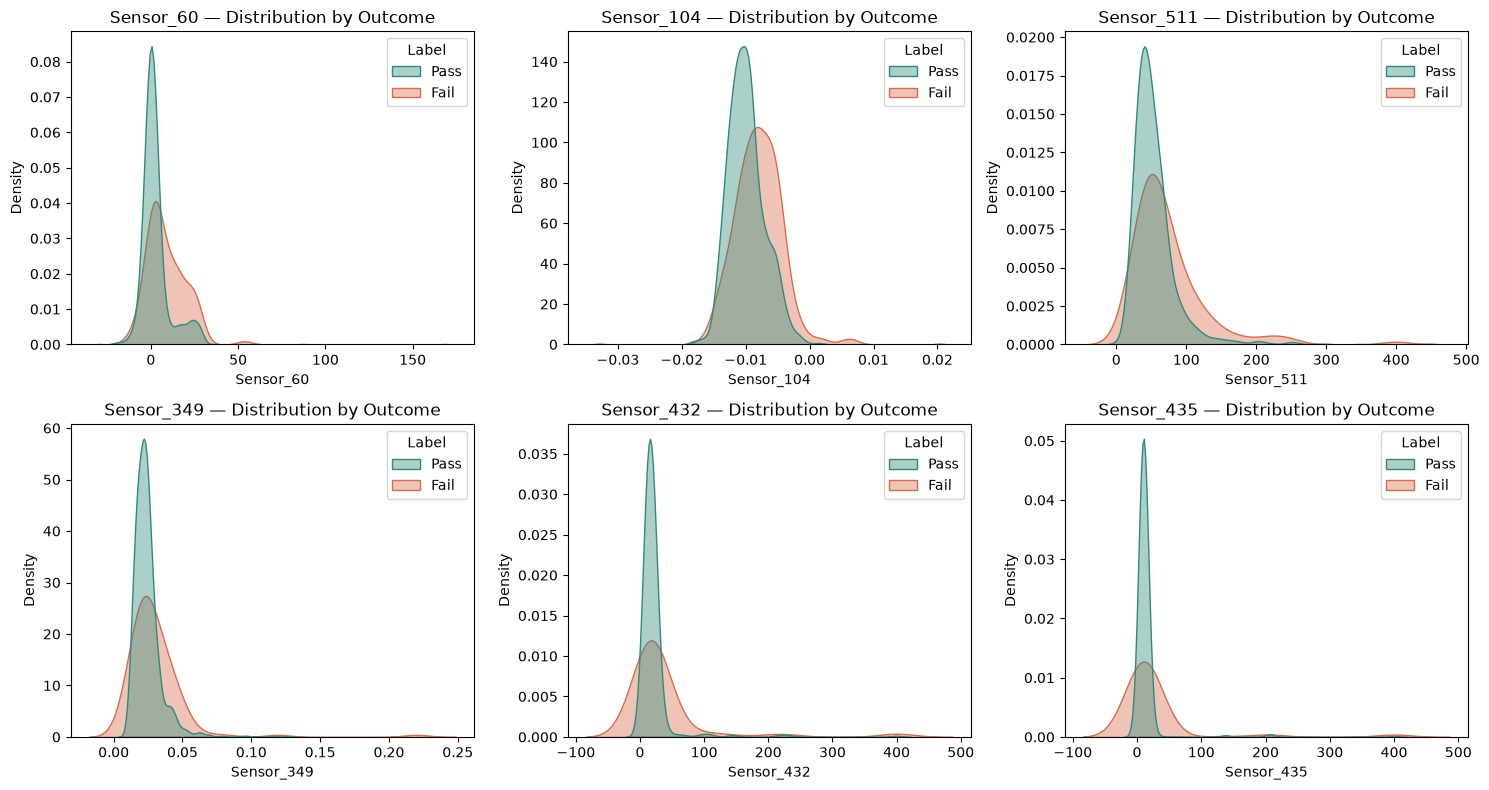

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, sensor in zip(axes.flat, top_sensors["Sensor"]):
    plot_sensor_pass_fail(df, sensor, ax)
plt.tight_layout()
plt.savefig("../reports/figures/top_sensor_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

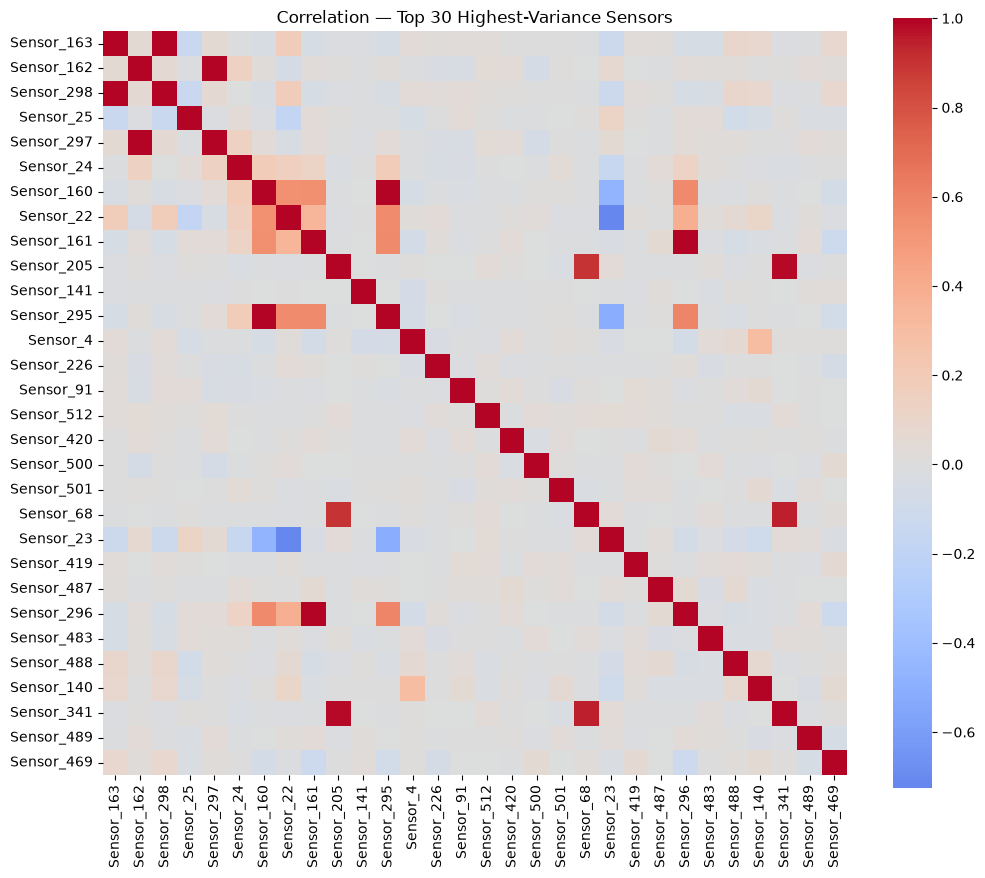

In [5]:
fig, ax = plt.subplots(figsize=(12, 10))
top_variance_correlation_heatmap(df, n=30, ax=ax)
plt.savefig("../reports/figures/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

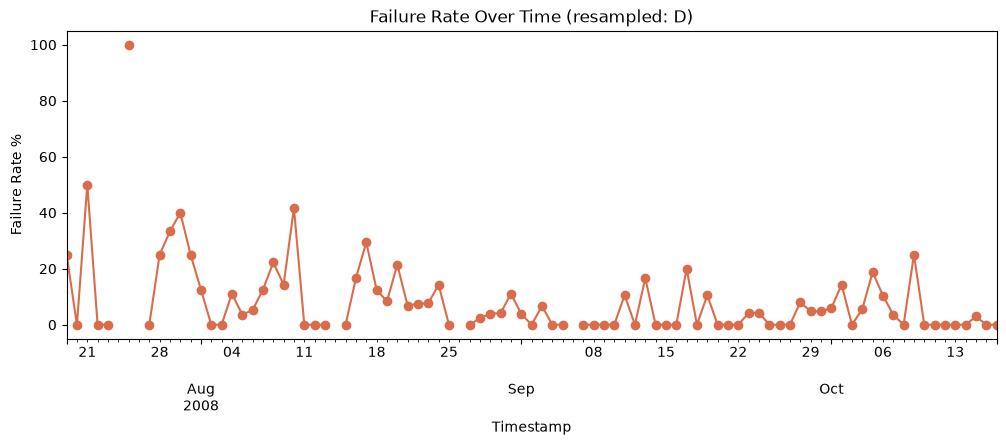

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_failure_rate_over_time(df, freq="D", ax=ax)
plt.savefig("../reports/figures/failure_rate_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

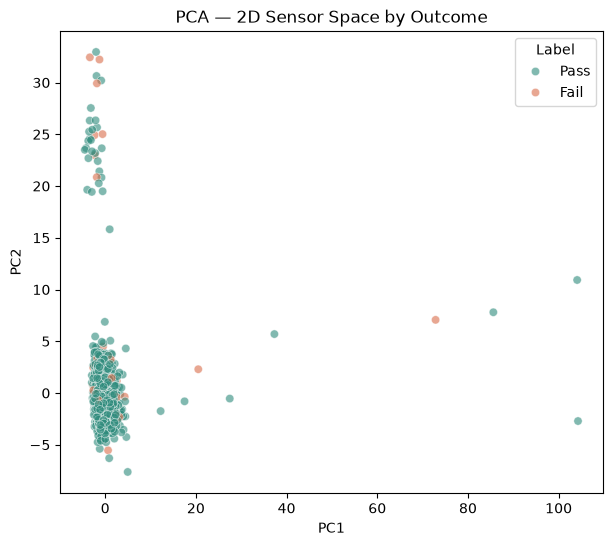

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_pca_scatter(df, ax)
plt.savefig("../reports/figures/pca_scatter.png", dpi=150, bbox_inches="tight")
plt.show()